# Model sanity check

**Purpose**: Smoke-test model wrappers (UNet / Mask R-CNN / WeakModel) and auxiliary utilities (feature extractor + PCA) on a few samples.

## Prerequisites
- Datasets available locally (update `data_dir`).
- CUDA optional but recommended for Mask R-CNN tests.
- scikit-learn installed (for PCA).

## How to run
- Run UNet section first (DeepCrack).
- Run Mask R-CNN section next (COCO-style).
- Finally run WeakModel + feature extractor checks.

## Notes
- Paths in this notebook are repository- and machine-specific; update them before running.
- If you're running from the `notebooks/` folder, the `PROJECT_ROOT` logic should work as-is.


In [1]:
import sys
import torch

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from pathlib import Path


PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))


from src.models import UNetModel, MaskRCNNModel, WeakModel, FeatureExtractor
from src.data_modules.factory import load_dataset

Data modules package initialized.


## UNet on segmentation (DeepCrack)
- Loads a DeepCrack sample, runs `model.predict`, and visualizes image / GT / prediction side-by-side.
- Then prints uncertainty via `model.get_uncertainty` (used by uncertainty sampling strategies).


In [2]:
class DummyConfig:
    dataset_type = "deepcrack"
    data_dir = "/home3/vzcl68/Datasets/DeepCrack/"
    img_size = 256
    num_classes = 2
    num_workers = 2
    batch_size = 2
    lr = 1e-3
    weight_decay = 1e-5
    task = "segmentation"

config = DummyConfig()
ds = load_dataset(config, split="train")

[DeepCrack] 300 samples loaded for split='train'


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNetModel(config.num_classes, device, config)

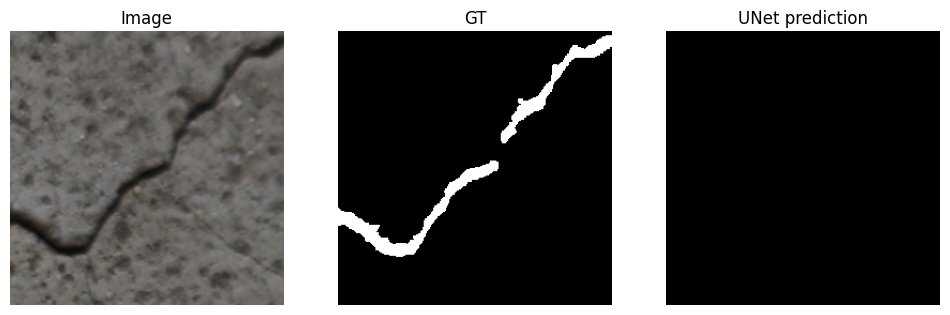

In [4]:
img, mask = ds[0]
pred = model.predict([img])[0]

mask_vis = mask.argmax(dim=0) if mask.dim() == 3 else mask

fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].imshow(img.permute(1, 2, 0))
axs[0].set_title("Image")

axs[1].imshow(mask_vis.cpu(), cmap="gray")
axs[1].set_title("GT")

# ---- prediction ----
if isinstance(pred, torch.Tensor):
    # UNet
    axs[2].imshow(pred.cpu(), cmap="gray")
    axs[2].set_title("UNet prediction")

elif isinstance(pred, dict):
    # Mask R-CNN
    if pred.get("masks") is not None and len(pred["masks"]) > 0:
        axs[2].imshow(pred["masks"][0, 0].cpu(), cmap="gray")
        axs[2].set_title("Mask R-CNN mask")
    else:
        axs[2].imshow(img.permute(1, 2, 0))
        axs[2].set_title("No detections")

for ax in axs:
    ax.axis("off")

plt.show()

In [5]:
u = model.get_uncertainty([img])
print("Uncertainty:", u)

Uncertainty: [0.69211054]


## Mask R-CNN on COCO-style dataset
- Loads COCO-style data, instantiates Mask R-CNN wrapper, runs prediction, and draws predicted boxes.
- Useful to verify that your dataset returns the expected `target` dict structure.


In [6]:
class DetConfig:
    dataset_type = "coco_segmentation"
    data_dir = '/home3/vzcl68/Datasets/Italian_Tunnel/'
    img_size = 256
    num_classes = 5        # background + categories
    num_workers = 2
    lr = 1e-3
    momentum = 0.9
    weight_decay = 1e-4
    lr_steps = [8, 11]
    
config = DetConfig()
train_ds = load_dataset(config, split="train")

loading annotations into memory...
Done (t=0.49s)
creating index...
index created!


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MaskRCNNModel(config.num_classes, device, config)

/home3/vzcl68/Code/MedCAL-Bench/MedCAL/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home3/vzcl68/Code/MedCAL-Bench/MedCAL/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


<class 'torch.Tensor'>


/home3/vzcl68/Code/MedCAL-Bench/MedCAL/lib/python3.10/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4317.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


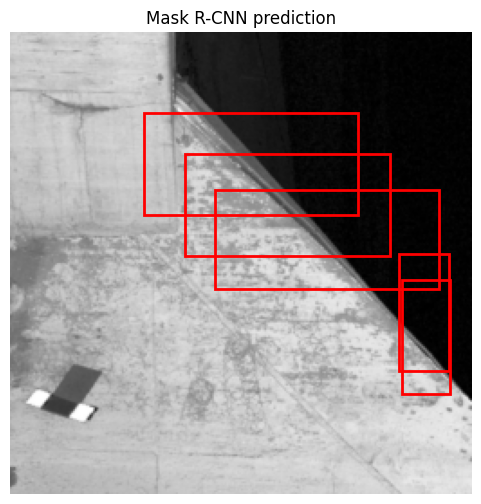

In [10]:
img, target = train_ds[0]
print(type(img))
pred = model.predict([img])[0]

fig, ax = plt.subplots(1, figsize=(6, 6))
ax.imshow(img.permute(1, 2, 0))

for box in pred["boxes"][:5]:
    x1, y1, x2, y2 = box.tolist()
    ax.add_patch(
        plt.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            fill=False, edgecolor="red", linewidth=2
        )
    )

ax.set_title("Mask R-CNN prediction")
ax.axis("off")
plt.show()

## Weak model + feature embeddings
- Computes cheap uncertainty estimates (baseline) and feature embeddings for diversity sampling.
- PCA plot is a quick check that features vary across samples.


In [11]:
weak = WeakModel(
    num_classes=config.num_classes,
    device=device
)

images = [train_ds[i][0] for i in range(4)]
unc = weak.get_uncertainty(images)

print("Weak model uncertainties:", unc)


Weak model uncertainties: [1.5546637 1.5735406 1.5664729 1.4622272]


In [12]:
fe = FeatureExtractor(model_name="resnet18")
features = fe.extract(images)

print("Feature shape:", features.shape)

Feature shape: torch.Size([4, 512])


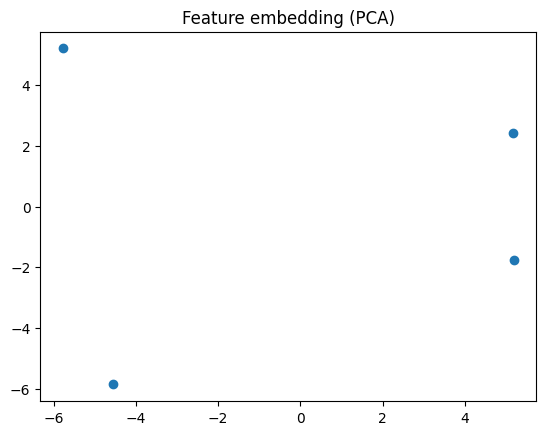

In [13]:
pca = PCA(n_components=2)
emb = pca.fit_transform(features)

plt.scatter(emb[:, 0], emb[:, 1])
plt.title("Feature embedding (PCA)")
plt.show()

## Troubleshooting
- **Blank/constant predictions**: verify preprocessing / normalization and that `num_classes` matches the dataset.
- **Mask R-CNN target errors**: COCO targets must include keys like `boxes`, `labels` (and `masks` for segmentation).
- **CUDA OOM**: reduce image size or batch size; Mask R-CNN is memory-heavy.
